# Regresi Linear

In [25]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [26]:
# Data Preparation
df = pd.read_excel("Final_PM15.xlsx")

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)

# X Variables
features = [
    '% NBKP', #1
    #'% BB Recycle',
    'Mean_Yankee Speed',
    'Mean_Stock Flow',
    'Mean_Flow Coating',
    'Mean_Load KWH Refiner', #2
    'Mean_Stock Consistency', #3
    'Mean_Creping', #4
    'Mean_Jet Wire Ratio' #5
]
X = df[features]

# Y Variables
df['y_variable'] = (df['MDT'] / df['GSM'])
target = df['y_variable']
y = target

# Konstanta
X = sm.add_constant(X)

import numpy as np
import matplotlib.pyplot as plt

for col in X.columns:
    plt.figure()
    plt.scatter(X[col], y)
    plt.title(col)
    plt.show()

In [27]:
X1 = df['GSM']
y1 = df['MDT']

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 185 entries, 21 to 356
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Start_Time              185 non-null    datetime64[us]
 1   End_Time                185 non-null    datetime64[us]
 2   Data_Count              185 non-null    int64         
 3   Mean_Creping            185 non-null    float64       
 4   Mean_Yankee Speed       185 non-null    float64       
 5   Mean_Pope Reel Speed    185 non-null    float64       
 6   Mean_Yankee Pressure    185 non-null    float64       
 7   Mean_Stock Flow         185 non-null    float64       
 8   Mean_Stock Consistency  185 non-null    float64       
 9   Mean_Flow Coating       185 non-null    float64       
 10  Mean_Flow Release       185 non-null    float64       
 11  Mean_Jet Wire Ratio     185 non-null    float64       
 12  Mean_Load KWH Refiner   185 non-null    float64       
 13  Join_

In [29]:
# Model Regresi Linear
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             y_variable   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     144.1
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           4.40e-73
Time:                        13:16:11   Log-Likelihood:                -513.56
No. Observations:                 185   AIC:                             1045.
Df Residuals:                     176   BIC:                             1074.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     75

## Pemeriksaan Asumsi IIDN

### Independen (Autokorelasi)

In [30]:
DW = sm.stats.durbin_watson(model.resid)
print('Nilai DW =', DW)
if DW == 2:
    print('Tidak ada autokorelasi (baik positif maupun negatif)')
elif DW < 2:
    print('Terdapat autokorelasi positif.')
elif DW > 2:
    print('Terdapat autokorelasi negatif.')

Nilai DW = 1.3260124707683436
Terdapat autokorelasi positif.


### Indentik (Heterokesdastisitas)

In [31]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan Test
# H0: Homoskedastisitas (Varians konstan)
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(21.07933643813448), 'LM-Test p-value': np.float64(0.006939638985075879), 'F-Statistic': np.float64(2.8290844580673364), 'F-Test p-value': np.float64(0.005609598686861881)}


Terjadi Heteroskedastisitas yang parah pada model. Varians dari residual terbukti secara empiris tidak konstan.

### Normalitas

In [32]:
# Libraries
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

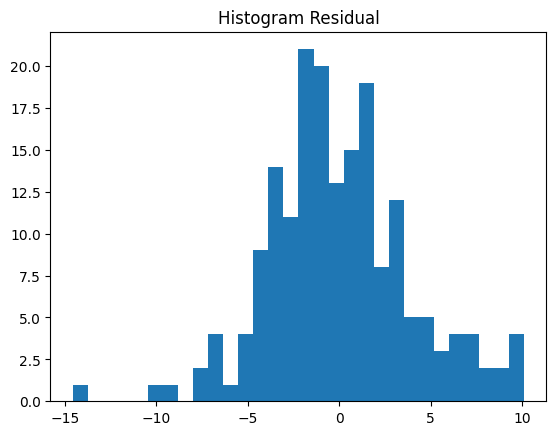

In [33]:
# Histogram
plt.figure()
plt.hist(model.resid, bins=30)
plt.title("Histogram Residual")
plt.show()

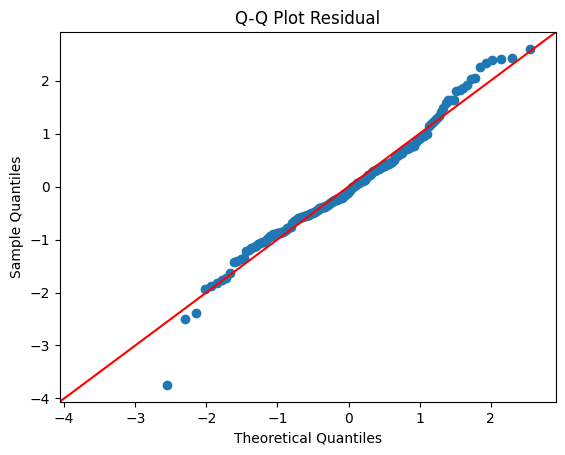

In [34]:
# Visualisasi (Q-Q Plot)
sm.qqplot(model.resid, line='45', fit=True)
plt.title("Q-Q Plot Residual")
plt.show()

In [35]:
# Uji Statistik (Shapiro-Wilk)
# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

stat, p_value = stats.shapiro(model.resid)

# Jika p-value < 0.05, residual tidak berdistribusi normal
print(f"Shapiro-Wilk Test: p-value = {p_value}")
if p_value < 0.05:
    print('residual tidak berdistribusi normal')
else:
    print('residual berdistribusi normal.')

Shapiro-Wilk Test: p-value = 0.01250162240919564
residual tidak berdistribusi normal


### Multikolinearitas

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

                  Feature           VIF
0                   const  27494.073505
1                  % NBKP     73.850772
2       Mean_Yankee Speed    124.661906
3         Mean_Stock Flow     11.138214
4       Mean_Flow Coating     47.276413
5   Mean_Load KWH Refiner     20.068261
6  Mean_Stock Consistency      2.857412
7            Mean_Creping     43.855830
8     Mean_Jet Wire Ratio      1.279221
